In [3]:
import pandas as pd
import numpy as np

In [5]:
# 导入数据
phone_one=pd.read_excel('./phone1.xlsx')
phone_two=pd.read_excel('./phone2.xlsx')

In [10]:
# 查看两个数据集的行列数跟列名
print('数据集1列名：',phone_one.columns)
print('数据集2列名：',phone_two.columns)
print('数据集1行列数：',phone_one.shape)
print('数据集2行列数：',phone_two.shape)

数据集1列名： Index(['id', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc',
       'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')
数据集2列名： Index(['id', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc',
       'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')
数据集1行列数： (2800, 22)
数据集2行列数： (3200, 22)


In [13]:
# 合并两个数据集
phone=pd.concat([phone_one,phone_two],ignore_index=True)
phone

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,226,1412,3476,12.0,7.0,2,0,1,0,3
1,2,841,1,0.5,1,4,1,61,0.8,191,...,746,857,3895,6.0,0.0,7,1,0,0,3
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,1270,1366,2396,17.0,10.0,10,0,1,1,2
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,295,1752,3893,10.0,0.0,7,1,1,0,3
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,749,810,1773,15.0,8.0,7,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5996,846,0,0.5,1,1,1,41,0.2,173,...,389,1016,3939,6.0,3.0,3,1,1,0,3
5996,5997,1922,0,2.6,0,0,1,59,0.9,138,...,1439,1924,3646,10.0,9.0,16,1,0,1,3
5997,5998,1017,0,1.7,1,0,1,5,0.7,179,...,890,1841,1850,10.0,5.0,11,1,0,1,1
5998,5999,1286,0,2.8,1,15,0,50,0.1,123,...,1178,1810,3129,17.0,6.0,2,0,0,0,3


In [17]:
# 清洗数据：检查有没缺失，有进行填充
print("每列缺失值数量：",phone.isnull().sum())
print("缺失值比例：",phone.isnull().sum()/len(phone)*100)

每列缺失值数量： id               0
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             1
sc_w             1
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
缺失值比例： id               0.000000
battery_power    0.000000
blue             0.000000
clock_speed      0.000000
dual_sim         0.000000
fc               0.000000
four_g           0.000000
int_memory       0.000000
m_dep            0.000000
mobile_wt        0.000000
n_cores          0.000000
pc               0.000000
px_height        0.000000
px_width         0.000000
ram              0.000000
sc_h             0.016667
sc_w             0.016667
talk_time        0.000000
three_g          0.000000
touch_screen     0.000000
wifi             0.000000
price_r

In [18]:
# 处理删除缺失值
phone1=phone.dropna(subset=['sc_h'],inplace=True)  #删除列缺失值的行
phone2=phone.dropna(axis=1,inplace=True)  #删除整列缺失的列

In [21]:
# Fill in the missing values
phone3=phone['sc_h'].fillna(phone['sc_h'].mean())   #使用均值填充

In [23]:
phone.bfill() #使用“bfill”方式填充，用后面有效值填充前面缺失值

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,talk_time,three_g,touch_screen,wifi,price_range
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12.0,2,0,1,0,3
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6.0,7,1,0,0,3
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17.0,10,0,1,1,2
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10.0,7,1,1,0,3
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15.0,7,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5996,846,0,0.5,1,1,1,41,0.2,173,...,2,389,1016,3939,6.0,3,1,1,0,3
5996,5997,1922,0,2.6,0,0,1,59,0.9,138,...,0,1439,1924,3646,10.0,16,1,0,1,3
5997,5998,1017,0,1.7,1,0,1,5,0.7,179,...,8,890,1841,1850,10.0,11,1,0,1,1
5998,5999,1286,0,2.8,1,15,0,50,0.1,123,...,20,1178,1810,3129,17.0,2,0,0,0,3


In [24]:
# 检查是否还有缺失值
phone.isnull().sum()

id               0
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [25]:
# 查找重复值
phone.duplicated().sum()

np.int64(0)

In [27]:
# 检查合并后数据中的手机厚度(m_dep)字段是否存在小于等于 0cm 的异常数据，若存在直接删除
len(phone.loc[phone['m_dep']<=0])

7

In [29]:
phone=phone.loc[phone['m_dep']>0].copy() #查找大于0的重新copy给原变量数据集，更新数据

In [30]:
len(phone.loc[phone['m_dep']<=0])

0

In [31]:
# 新增一个字段
phone['屏幕尺寸']=(phone['px_height']**2 + phone['px_width']**2)**0.5

In [32]:
# 查看新增字段新的数据集前十行
phone.head(10)

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,talk_time,three_g,touch_screen,wifi,price_range,屏幕尺寸
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,226,1412,3476,12.0,2,0,1,0,3,1429.972028
1,2,841,1,0.5,1,4,1,61,0.8,191,...,746,857,3895,6.0,7,1,0,0,3,1136.206407
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,1270,1366,2396,17.0,10,0,1,1,2,1865.169161
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,295,1752,3893,10.0,7,1,1,0,3,1776.662320
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,749,810,1773,15.0,7,1,0,1,1,1103.223006
5,6,1464,1,2.9,1,5,1,50,0.8,198,...,569,939,3506,10.0,3,1,1,1,3,1097.944443
6,7,1718,0,2.4,0,1,0,47,1.0,156,...,1283,1374,3873,14.0,10,0,0,0,3,1879.884305
7,8,833,0,2.4,1,0,0,62,0.8,111,...,1312,1880,1495,7.0,18,0,1,1,1,2292.540948
8,9,1111,1,2.9,1,9,1,25,0.6,101,...,556,876,3485,11.0,10,1,1,0,3,1037.550963
9,10,1520,0,0.5,0,1,0,25,0.5,171,...,52,1009,651,6.0,5,1,0,1,0,1010.339052


使用seaborn库,可视化数据

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = 'SimHei'  # 正常显示中文
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

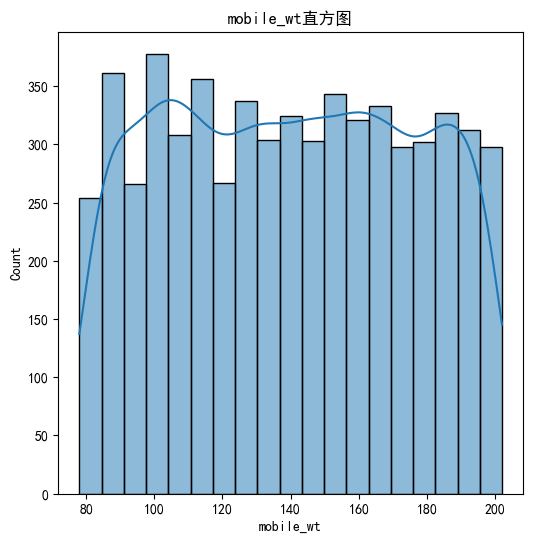

In [35]:
# 绘制手机重量直方图（查看分布）
plt.figure(figsize=(6,6)) #设置图表大小
plt.title('mobile_wt直方图')
sns.histplot(phone['mobile_wt'],kde=True)
plt.show()

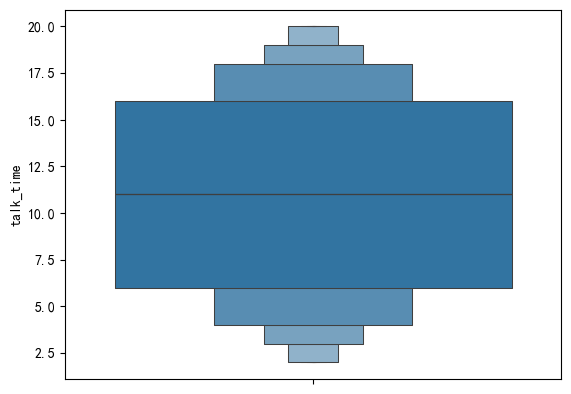

In [39]:
# 绘制箱线图（查看异常值）
# plt.figure(figsize=(7,6))
sns.boxenplot(phone['talk_time'])
plt.show()

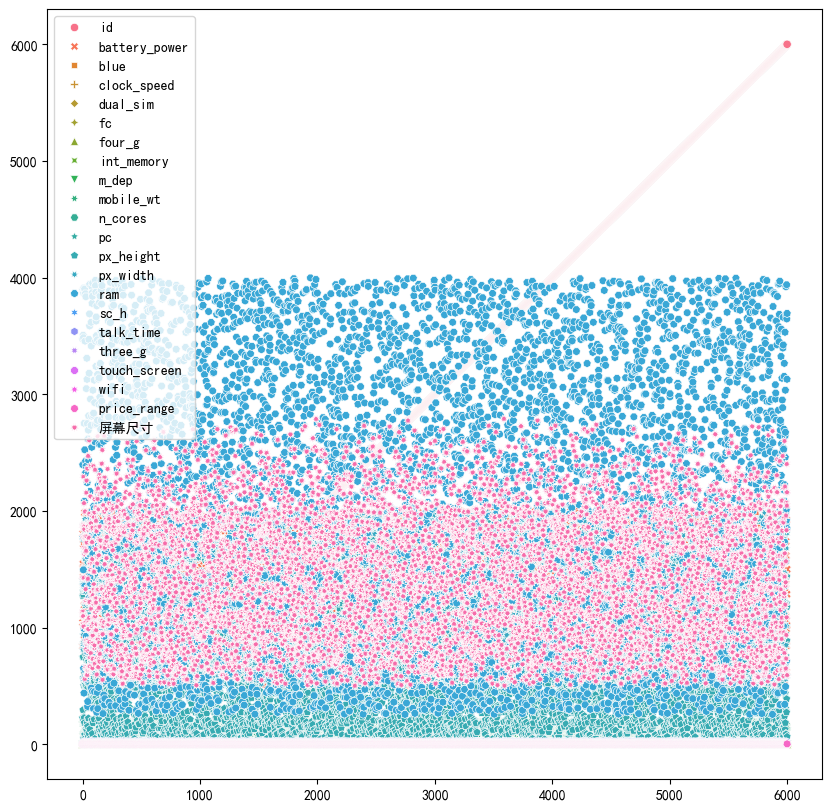

In [42]:
# 绘制散点图(查看关系)
plt.figure(figsize=(10,10))
sns.scatterplot(phone)
plt.show()

In [43]:
# 统计dual_sim，four_g，three_g，touch_screen频数和占比，再用饼图展示分布情况

